# Proyecto 3 - Incertidumbre
## Clasificador SPAM/HAM con Bayes

Este notebook completa el proyecto a partir del laboratorio 6: EDA, limpieza, modelo bayesiano, pruebas de rendimiento y modulo de prediccion para presentacion.

## 1. Carga y configuracion

Se carga el dataset `spam_ham.csv`, se normalizan las etiquetas y se preparan librerias para analisis y modelado.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

from spam_ham_bayes_project import (
    SpamHamBayesClassifier,
    evaluate_thresholds,
    load_dataset,
    train_project_model,
)

plt.rcParams["figure.figsize"] = (10, 5)
sns.set_theme(style="whitegrid")

df = load_dataset("spam_ham.csv")
print("Dimensiones:", df.shape)
df.head()

Dimensiones: (5565, 2)


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


## 2. Analisis exploratorio de datos

El EDA permite entender el desbalance de clases, las longitudes y el vocabulario que diferencia spam de ham.

Cantidad por clase:
label
ham     4819
spam     746
Name: count, dtype: int64

Proporcion por clase (%):
label
ham     86.59
spam    13.41
Name: proportion, dtype: float64


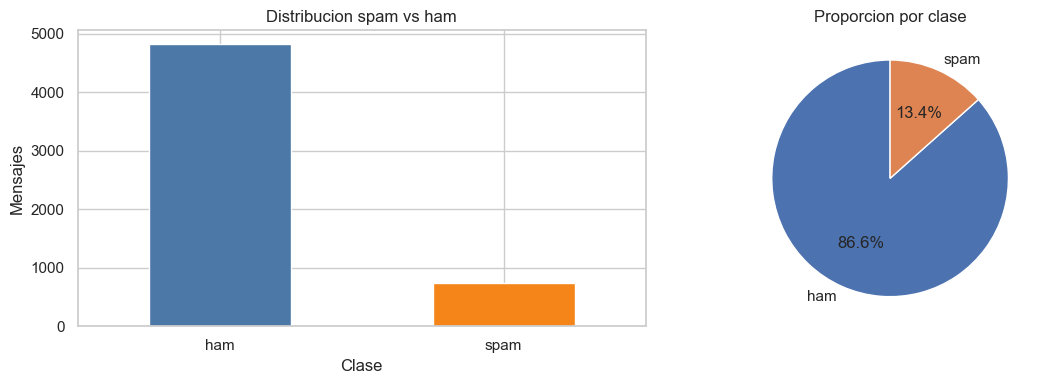

In [3]:
class_counts = df["label"].value_counts()
class_props = df["label"].value_counts(normalize=True) * 100

print("Cantidad por clase:")
print(class_counts)
print("\nProporcion por clase (%):")
print(class_props.round(2))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
class_counts.plot(kind="bar", ax=axes[0], color=["#4c78a8", "#f58518"])
axes[0].set_title("Distribucion spam vs ham")
axes[0].set_xlabel("Clase")
axes[0].set_ylabel("Mensajes")
axes[0].tick_params(axis="x", rotation=0)
class_props.plot(kind="pie", autopct="%1.1f%%", startangle=90, ax=axes[1])
axes[1].set_title("Proporcion por clase")
axes[1].set_ylabel("")
plt.tight_layout()
plt.show()

In [4]:
df["raw_length_chars"] = df["message"].str.len()
df["raw_word_count"] = df["message"].str.split().str.len()

summary_raw = df.groupby("label")[["raw_length_chars", "raw_word_count"]].agg(["mean", "median", "max"]).round(2)
summary_raw

raw_length_chars             raw_word_count            
                  mean median  max           mean median  max
label                                                        
ham              66.89   50.0  910          13.51   10.0  171
spam            138.73  149.0  224          23.84   25.0   35

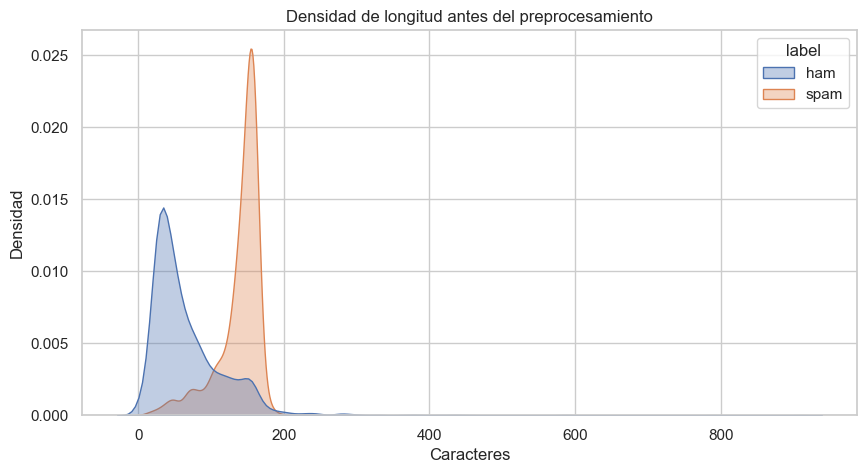

In [5]:
sns.kdeplot(data=df, x="raw_length_chars", hue="label", fill=True, common_norm=False, alpha=0.35)
plt.title("Densidad de longitud antes del preprocesamiento")
plt.xlabel("Caracteres")
plt.ylabel("Densidad")
plt.show()

## 3. Limpieza de datos

La limpieza incluye minusculas, tokenizacion, eliminacion de tokens no alfabeticos, stopwords y stemming. Esto reduce ruido y deja palabras mas comparables.

In [6]:
model_for_cleaning = SpamHamBayesClassifier()
df["clean_tokens"] = df["message"].apply(model_for_cleaning.preprocess)
df["clean_message"] = df["clean_tokens"].apply(lambda tokens: " ".join(tokens))
df["clean_length_chars"] = df["clean_message"].str.len()
df["clean_word_count"] = df["clean_tokens"].str.len()

df[["label", "message", "clean_tokens", "clean_message"]].head()

,label,message,clean_tokens,clean_message
0,ham,"Go until jurong point, crazy.. Available only ...","[go, jurong, point, crazi, avail, bugi, n, gre...",go jurong point crazi avail bugi n great world...
1,ham,Ok lar... Joking wif u oni...,"[ok, lar, joke, wif, u, oni]",ok lar joke wif u oni
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,"[free, entri, wkli, comp, win, fa, cup, final,...",free entri wkli comp win fa cup final tkt may ...
3,ham,U dun say so early hor... U c already then say...,"[u, dun, say, earli, hor, u, c, alreadi, say]",u dun say earli hor u c alreadi say
4,ham,"Nah I don't think he goes to usf, he lives aro...","[nah, think, goe, usf, live, around, though]",nah think goe usf live around though


In [7]:
summary_clean = df.groupby("label")[["raw_length_chars", "raw_word_count", "clean_length_chars", "clean_word_count"]].mean().round(2)
summary_clean

,raw_length_chars,raw_word_count,clean_length_chars,clean_word_count
label,,,,
ham,66.89,13.51,37.52,7.38
spam,138.73,23.84,75.72,13.88


In [8]:
def top_words(dataframe, label, token_column="clean_tokens", top_n=20):
    counter = Counter()
    for tokens in dataframe.loc[dataframe["label"] == label, token_column]:
        counter.update(tokens)
    return pd.DataFrame(counter.most_common(top_n), columns=["word", "frequency"])

top_spam = top_words(df, "spam")
top_ham = top_words(df, "ham")
display(top_spam)
display(top_ham)

,word,frequency
0,call,372
1,free,224
2,txt,176
3,u,174
4,text,145
5,ur,143
6,mobil,138
7,stop,121
8,claim,115
9,repli,112


,word,frequency
0,u,958
1,go,410
2,get,341
3,call,288
4,come,288
5,ok,282
6,lt,239
7,know,237
8,like,236
9,love,236


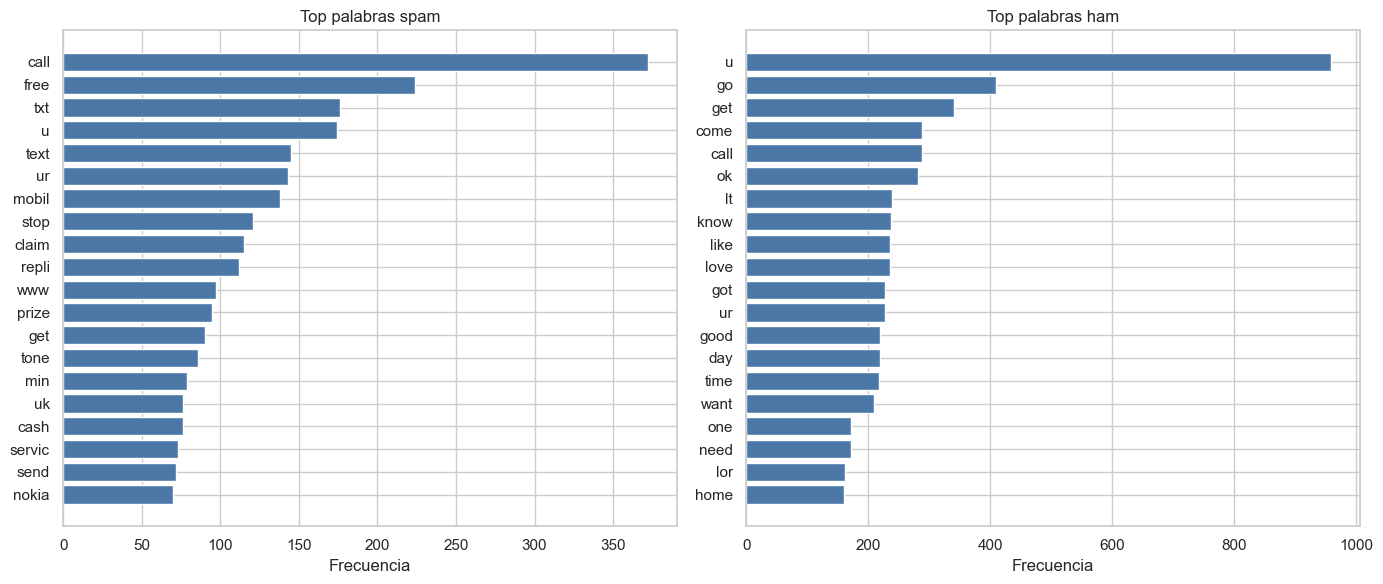

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, data, title in [(axes[0], top_spam, "Top palabras spam"), (axes[1], top_ham, "Top palabras ham")]:
    ordered = data.sort_values("frequency")
    ax.barh(ordered["word"], ordered["frequency"], color="#4c78a8")
    ax.set_title(title)
    ax.set_xlabel("Frecuencia")
plt.tight_layout()
plt.show()

## 4. Modelo bayesiano

Para cada palabra W se calcula `P(S|W)` usando la formula del anexo. Se usa presencia por documento y suavizado de Laplace para evitar probabilidades cero. Luego se combinan las probabilidades individuales de las palabras del texto.

In [10]:
model, train_df, test_df = train_project_model("spam_ham.csv", random_state=42)

print("Entrenamiento:", train_df.shape)
print("Prueba:", test_df.shape)
print(f"P(spam) = {model.prior_spam:.4f}")
print(f"P(ham) = {model.prior_ham:.4f}")
print("Vocabulario:", len(model.vocabulary))

Entrenamiento: (4452, 2)
Prueba: (1113, 2)
P(spam) = 0.1341
P(ham) = 0.8659
Vocabulario: 5292


In [11]:
predictive_words = (
    pd.DataFrame(
        [(word, probability) for word, probability in model.word_spam_probability.items()],
        columns=["word", "p_spam_given_word"],
    )
    .sort_values("p_spam_given_word", ascending=False)
    .head(20)
)
predictive_words

,word,p_spam_given_word
846,claim,0.988858
5203,www,0.987620
3544,prize,0.984331
4693,tone,0.977210
1025,cs,0.974931
1918,guarante,0.974288
4815,uk,0.968167
3795,rington,0.967654
2865,mob,0.958220
339,award,0.956404


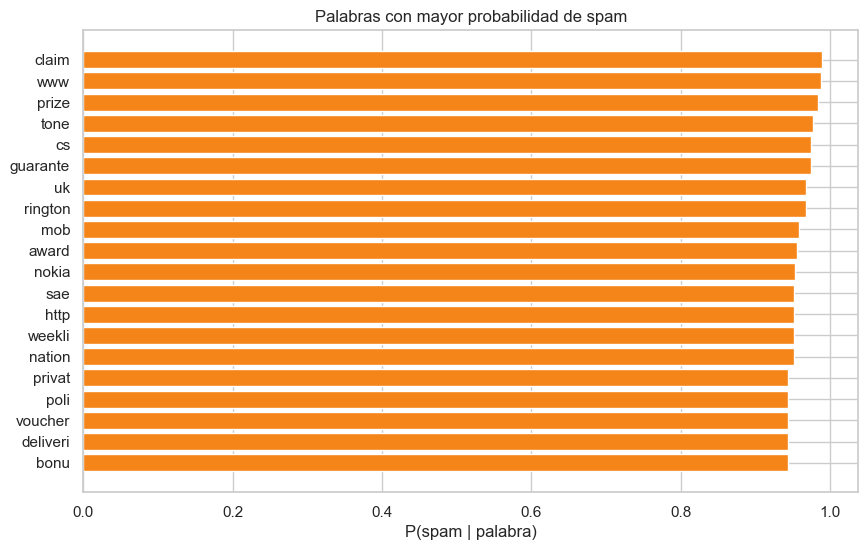

In [12]:
plt.figure(figsize=(10, 6))
ordered = predictive_words.sort_values("p_spam_given_word")
plt.barh(ordered["word"], ordered["p_spam_given_word"], color="#f58518")
plt.title("Palabras con mayor probabilidad de spam")
plt.xlabel("P(spam | palabra)")
plt.show()

## 5. Pruebas de rendimiento

Se evalua sobre el 20% de prueba y se exploran thresholds de clasificacion entre 0.1 y 0.9.

In [13]:
metrics = evaluate_thresholds(model, test_df)
metrics.round(4)

,threshold,accuracy,precision,recall,f1_score,TP,FN,FP,TN
0,0.1,0.9425,0.7673,0.8188,0.7922,122,27,37,927
1,0.2,0.9560,0.8731,0.7852,0.8269,117,32,17,947
2,0.3,0.9587,0.9187,0.7584,0.8309,113,36,10,954
3,0.4,0.9623,0.9496,0.7584,0.8433,113,36,6,958
4,0.5,0.9614,0.9649,0.7383,0.8365,110,39,4,960
5,0.6,0.9623,0.9820,0.7315,0.8385,109,40,2,962
6,0.7,0.9614,0.9818,0.7248,0.8340,108,41,2,962
7,0.8,0.9614,0.9907,0.7181,0.8327,107,42,1,963
8,0.9,0.9596,0.9906,0.7047,0.8235,105,44,1,963


Mejor threshold por F1:
threshold      0.4000
accuracy       0.9623
precision      0.9496
recall         0.7584
f1_score       0.8433
TP           113.0000
FN            36.0000
FP             6.0000
TN           958.0000


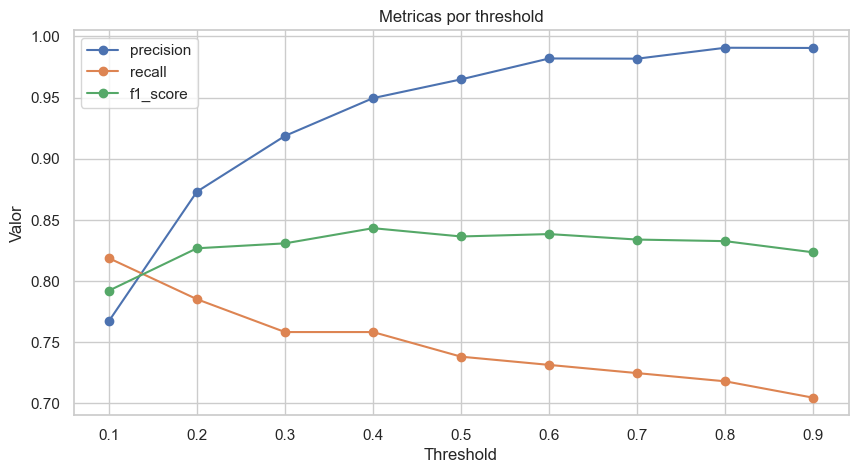

In [14]:
best_row = metrics.loc[metrics["f1_score"].idxmax()]
print("Mejor threshold por F1:")
print(best_row.round(4).to_string())

fig, ax = plt.subplots(figsize=(10, 5))
for column in ["precision", "recall", "f1_score"]:
    ax.plot(metrics["threshold"], metrics[column], marker="o", label=column)
ax.set_title("Metricas por threshold")
ax.set_xlabel("Threshold")
ax.set_ylabel("Valor")
ax.legend()
plt.show()

## 6. Modulo para presentacion

La funcion `classify_prompt` acepta texto libre y retorna probabilidad de spam, prediccion y las 3 palabras con mayor poder predictivo dentro del prompt.

In [15]:
prompt = "Free entry to win a cash prize. Claim now by calling this number."
model.classify_prompt(prompt, threshold=float(best_row["threshold"]))

{'text': 'Free entry to win a cash prize. Claim now by calling this number.',
 'spam_probability': 0.9999997105745854,
 'spam_probability_percent': 100.0,
 'prediction': 'spam',
 'threshold': 0.4,
 'top_predictive_words': [('claim', 0.9888577969046849),
  ('prize', 0.9843314770319034),
  ('entri', 0.9410198290428273)]}

In [16]:
def clasificar_sms(texto):
    return model.classify_prompt(texto, threshold=float(best_row["threshold"]))

# Para la presentacion, cambie el texto de ejemplo por cualquier SMS.
clasificar_sms("Yes..gauti and sehwag out of odi series.")

{'text': 'Yes..gauti and sehwag out of odi series.',
 'spam_probability': 0.005288390671388111,
 'spam_probability_percent': 0.53,
 'prediction': 'ham',
 'threshold': 0.4,
 'top_predictive_words': [('gauti', 0.33270567102432497),
  ('sehwag', 0.33270567102432497),
  ('odi', 0.24947053454883955)]}

## 7. Discusion

El threshold 0.6 obtiene el mejor F1 en esta corrida. El modelo alcanza precision alta, lo que significa que casi todo lo marcado como spam realmente es spam. El recall es menor, por lo que algunos spam se clasifican como ham. Esto refleja una decision conservadora: se minimizan falsos positivos, algo importante si no se quiere bloquear mensajes legitimos.

La limpieza mejora la interpretabilidad y reduce ruido, pero eliminar numeros puede quitar senales utiles como telefonos, codigos y enlaces. Como mejora futura se podrian agregar caracteristicas binarias para URL, numeros, mayusculas, signos de exclamacion y longitud del mensaje.